In [6]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

In [7]:
X1 = pd.read_csv("A2AR/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("A2AR/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("A2AR/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("A2AR/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("A2AR/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("A2AR/mod_data/y3.1", index_col="QSPRID")


In [8]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,3066,3067,3068,3069,3070,3071,3072,3073,3074,3075
0,0.629350,0.409822,0.114763,0.849649,-1.302256,-1.582738,-0.678928,-1.233195,-1.434335,-1.134524,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.233341
1,1.225274,0.942670,-0.168389,-0.169440,-0.341978,-0.052202,2.212653,0.803415,0.814574,0.266891,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,4.974340,-0.279983,-1.882446
2,-0.982475,0.726753,-1.033329,1.253848,-0.652347,0.063208,0.950025,-0.664100,-1.904197,-1.753757,...,-0.081803,2.465924,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,2.249445
3,1.324123,1.301264,0.499300,-2.170308,-0.573437,-1.556576,0.760613,0.555091,-0.346715,-0.279360,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,2.389444,-0.279983,-1.263797
4,0.402699,0.209699,0.333955,1.363094,-1.035884,-1.581501,-0.340915,-0.499982,-1.004890,-1.360252,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,1.151519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.032254,0.229924,0.599687,-2.032301,-0.221510,-0.969474,0.562910,0.238983,-1.371945,-0.892411,...,-0.081803,1.057649,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.090632
4630,0.852744,2.780378,-0.303757,0.045130,-0.705685,0.354237,2.359929,0.399819,-0.237312,-0.480343,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-0.886180
4631,1.077851,0.406309,0.009425,-2.073997,-0.936921,-0.010000,0.142849,-0.608348,-0.839790,-0.252830,...,-0.081803,-0.341777,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,0.321485
4632,0.728076,1.615808,0.402721,-0.872904,-0.449266,0.046455,1.877900,0.718067,-0.754062,-0.452396,...,-0.081803,1.411798,-0.116076,-0.184214,-0.057747,-0.310778,-0.239901,-0.195451,-0.279983,-1.019934


In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [11]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [12]:
n_components

741

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

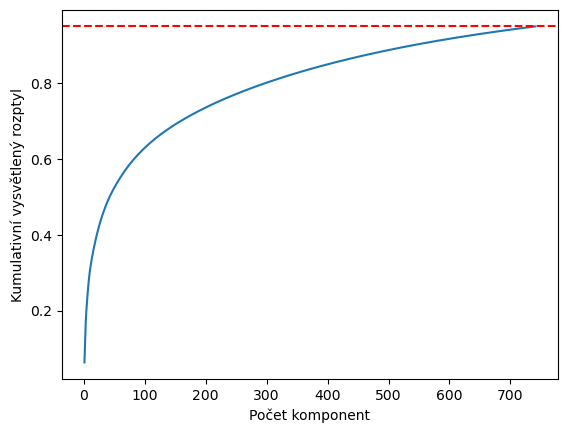

In [15]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=8)

In [17]:
pred = knn.predict(X2)

In [18]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.7953144266337855
Mcc: 0.19994063986363164


In [19]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid({
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],  # různé hodnoty K
    'weights': ['uniform', 'distance'],             # vážení sousedů
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # různé metriky vzdálenosti
    'p': [1, 2],                                     # pro minkowski: p=1 (Manhattan), p=2 (Eukleidovská)
    'leaf_size': [10, 20, 30, 50, 100],              # ovlivňuje rychlost vyhledávání
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']  # různé algoritmy pro hledání sousedů
})

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    knn = KNeighborsClassifier(**param)
    knn.fit(X1, y1["Y"])
    pred = knn.predict(X2)
    val_mcc.append(matthews_corrcoef(pred, y2["Y"]))
    val_f1.append(f1_score(pred, y2["Y"]))
    val_acc.append(accuracy_score(pred, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred, y2["Y"]))



  0%|                                              | 2/2880 [00:00<10:43,  4.47it/s]

Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'} 
MCC: 0.2956546979148116
Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 1, 'weights': 'distance'} 
MCC: 0.2956546979148116


  0%|                                              | 4/2880 [00:00<09:16,  5.17it/s]

Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 2, 'weights': 'uniform'} 
MCC: 0.2956546979148116
Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 2, 'weights': 'distance'} 
MCC: 0.2956546979148116


  0%|                                              | 6/2880 [00:01<09:08,  5.24it/s]

...

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 1, 'weights': 'distance'} 
MCC: 0.11622530990817895


100%|████████████████████████████████████████▉| 2879/2880 [8:39:50<00:01,  1.32s/it]

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 2, 'weights': 'uniform'} 
MCC: 0.155613122677348


100%|█████████████████████████████████████████| 2880/2880 [8:39:50<00:00, 10.83s/it]

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 2, 'weights': 'distance'} 
MCC: 0.1584628995276332


In [20]:
knn_res = pd.DataFrame(param_grid)

In [21]:
knn_res["mcc"] = val_mcc
knn_res["f1"] = val_f1
knn_res["acc"] = val_acc

In [22]:
knn_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [23]:
knn_res.to_csv("A2AR/res/knn_res_val_1.1.csv")

In [24]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [25]:
best_params

{'weights': 'uniform',
 'p': 1,
 'n_neighbors': 1,
 'metric': 'chebyshev',
 'leaf_size': 10,
 'algorithm': 'auto'}

In [26]:
knn = KNeighborsClassifier(**best_params)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(leaf_size=10, metric='chebyshev', n_neighbors=1, p=1)

In [27]:
pred = knn.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.9457459926017263
F1: 0.9716129032258064
Mcc: 0.3669351708395089


In [29]:
pred_test = knn.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.9178240740740741
F1: 0.9565749235474006
Mcc: 0.214280517737838


In [32]:
from sklearn.linear_model import LinearRegression

In [39]:
lin = LinearRegression()

In [40]:
lin.fit(X1, y1.Y)

LinearRegression()

In [42]:
pred_lin = lin.predict(X2) > 0.5

print("Acc:", accuracy_score(pred_lin, y2))
print("F1:", f1_score(pred_lin, y2))
print("Mcc:", matthews_corrcoef(pred_lin, y2))

Acc: 0.938347718865598
F1: 0.9679075738125802
Mcc: 0.18718460430887904


In [43]:
df3 = pd.read_csv("HIV/data/hiv_test_1")
df2 = pd.read_csv("HIV/data/hiv_val_1")
df1 = pd.read_csv("HIV/data/hiv_train_1")

In [44]:
df_all_hiv = pd.concat([df1.Drug, df2.Drug, df3.Drug])

In [45]:
len(df_all_hiv)

40670

In [47]:
len(set(df_all_hiv))

40564